# **Q1: Plot the data (i.e., x-axis for the 1st column, y-axis for the 2nd column)**

In [5]:
# Import Statements
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [6]:
# Read the data from the given text file
data = pd.read_csv('./data2.txt', sep = ',', header = None)

# Name the columns of the given data
data.columns = ['x', 'y']

In [7]:
# Describe the Data
data.describe()

,x,y
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


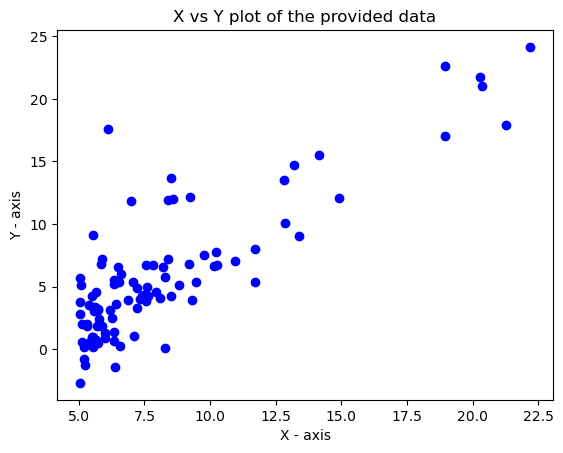

In [8]:
# Plot data X and and Y points
plt.plot(data.x, data.y, 'bo')

# Set the label for the x-axis
plt.xlabel('X - axis')

# Set the label for the y-axis
plt.ylabel('Y - axis')

# Set the title of the plot
plt.title('X vs Y plot of the provided data')

# Display the plot
plt.show()

# Q2: Python implementation to find the coefficients Normal equation

In [9]:
# np.c_ is used to concatenate arrays along the second axis (columns).
# np.ones((len(data.x), 1)) creates a column of ones to represent the intercept term.
X_normal = np.c_[np.ones((len(data.x), 1)), data.x]

# Assign the target variable Y
Y_normal = data.y

# This line computes theta using the normal equation
# theta = (X^T * X)^(-1) * X^T * Y
theta_normal = np.linalg.inv(X_normal.T.dot(X_normal)).dot(X_normal.T).dot(Y_normal)

In [10]:
theta_normal

array([-3.89578088,  1.19303364])

In [11]:
#Create testing dataset to plot the line
X_test = np.c_[np.ones(len(data.x)), np.array(data.x)]

# Compute predictions
Y_predict = X_test.dot(theta_normal)

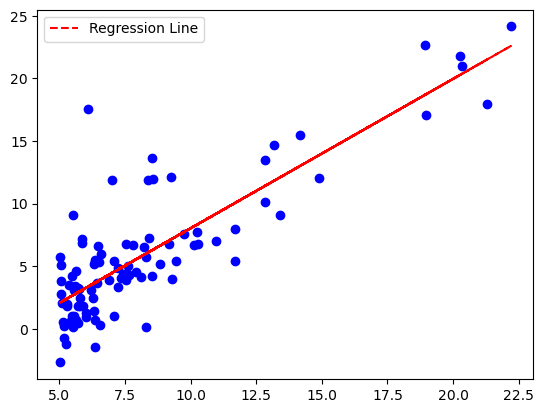

In [12]:
# Plot the data points (x vs. y)
plt.plot(data.x, data.y, 'bo')

# Plot the predicted regression line
plt.plot(X_test[:, 1], Y_predict, 'r--', label='Regression Line')

# Add a legend to the plot to distinguish between the data points and the regression line
plt.legend()

plt.show()

# Batch Gradient Descent

In [13]:
# Transform the dataframe to a numpy array
X = np.array(data.x)
Y = np.array(data.y)

# np.c_ is used to concatenate arrays along the second axis (columns).
# np.ones((len(data.x), 1)) creates a column of ones to represent the intercept term.
X_grad = np.c_[np.ones((len(X),1)), X]

# Reshape the array
Y_grad = Y.reshape(len(X),1)

# Split the dataset into training and testing sets
X_grad_train, X_grad_test, Y_grad_train, Y_grad_test = train_test_split(X_grad, Y_grad, test_size=0.2, random_state=50)

In [14]:
def batch_gd_predict(theta, X) :
    # Calculate the predictions by performing the dot product between input features and model parameters
    predictions = X.dot(theta)
    return predictions

In [15]:
def batch_gd_MSE(predictions, Y) :
    # Compute Mean Squared Error
    mse = np.mean((predictions - Y)**2) / 2
    return mse

In [16]:
import numpy as np
def batch_gradient_descent(X, Y, learning_rate, threshold):
    # Initialize theta with zeros
    theta = np.zeros((2, 1))

    # List to store mean squared error values
    batch_mse_vals = []

    # Make initial predictions using the current parameters
    predictions = batch_gd_predict(theta, X)

    # Initialize iteration counter and previous MSE
    iter = 0
    previous_mse = batch_gd_MSE(predictions, Y)

    # Continue looping until the difference between consecutive MSE is less than the threshold
    while True:
        # Calculate the error between predictions and actual values
        error = predictions - Y

        # Store the current iteration and MSE
        current_mse = previous_mse
        batch_mse_vals.append([iter, current_mse])

        # Compute the gradient of the loss function
        gradient = 2 * X.T.dot(error) / len(X)

        # Update theta using the gradient and learning rate
        theta = theta - learning_rate * gradient

        # Update predictions with new parameters
        predictions = batch_gd_predict(theta, X)
        
        # Calculate new MSE
        new_mse = batch_gd_MSE(predictions, Y)
        
        # Calculate the difference between current and new MSE
        mse_difference = abs(new_mse - current_mse)
        
        # Print the MSE and the difference for every 10,000 iterations for monitoring purpose
        if iter % 100 == 0:
            print("MSE for iteration " + str(iter) + " : ", current_mse)
            print("Difference in MSE from previous iteration: ", mse_difference)
        
        # Check if the difference between consecutive MSE is less than the threshold
        if mse_difference < threshold:
            break
        
        # Update previous MSE for the next iteration
        previous_mse = new_mse

        # Increment the iteration counter
        iter += 1

    # Return the final parameters and the list of MSE values
    return theta, batch_mse_vals

In [17]:
# Call the Batch Gradient Descent function on Training Dataset
batch_gd_theta_train, batch_gd_mse_train = batch_gradient_descent(X_grad_train, Y_grad_train, learning_rate = 0.001, threshold = 0.0000001)

MSE for iteration 0 :  33.83799032446039
Difference in MSE from previous iteration:  8.835622623673668
MSE for iteration 100 :  6.000444235859312
Difference in MSE from previous iteration:  0.0009752151203414883
MSE for iteration 200 :  5.906437127056114
Difference in MSE from previous iteration:  0.0009050976844280356
MSE for iteration 300 :  5.819189078166358
Difference in MSE from previous iteration:  0.0008400216539596883
MSE for iteration 400 :  5.738214116464206
Difference in MSE from previous iteration:  0.0007796245546343172
MSE for iteration 500 :  5.6630612103980775
Difference in MSE from previous iteration:  0.0007235699738510348
MSE for iteration 600 :  5.593311757339248
Difference in MSE from previous iteration:  0.0006715456868882086
MSE for iteration 700 :  5.528577251959977
Difference in MSE from previous iteration:  0.0006232619178190291
MSE for iteration 800 :  5.468497122253949
Difference in MSE from previous iteration:  0.0005784497254426313
MSE for iteration 900 : 

In [18]:
print("Optimized Theta for Batch Gradient Descent on Training Dataset : ", batch_gd_theta_train)

Optimized Theta for Batch Gradient Descent on Training Dataset :  [[-3.75379693]
 [ 1.16573417]]


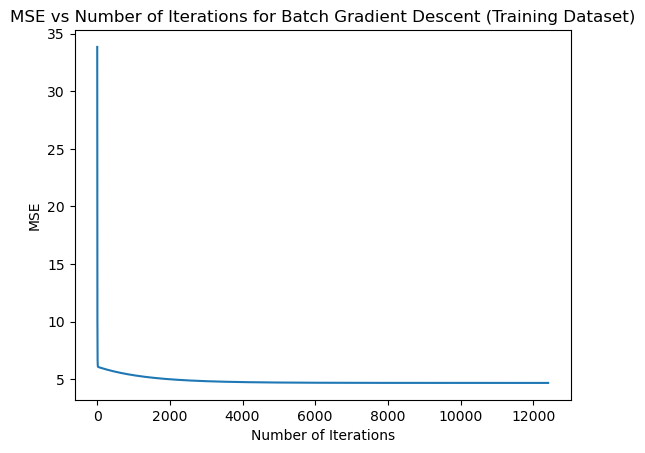

In [19]:
# Extract iteration numbers on training dataset
iter = [batch_gd_mse_train[i][0] for i in range(len(batch_gd_mse_train))]

# Extract MSE values on the training dataset
mse = [batch_gd_mse_train[i][1] for i in range(len(batch_gd_mse_train))]

# Plot the data points
plt.plot(iter, mse)
# Set the label for X - axis
plt.xlabel("Number of Iterations")
# Set the label for Y - axis
plt.ylabel("MSE")
# Set the title
plt.title('MSE vs Number of Iterations for Batch Gradient Descent (Training Dataset)')
plt.show()

In [20]:
# Call the Batch Gradient Descent function on Testing Dataset
batch_gd_theta_test, batch_gd_mse_test = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.001, threshold = 0.0000001)

MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  4.735983435880435
MSE for iteration 100 :  5.105997695367107
Difference in MSE from previous iteration:  0.0009396764819671333
MSE for iteration 200 :  5.014461858998132
Difference in MSE from previous iteration:  0.0008909850718827883
MSE for iteration 300 :  4.927669153076057
Difference in MSE from previous iteration:  0.0008448167234558213
MSE for iteration 400 :  4.845373801839704
Difference in MSE from previous iteration:  0.0008010406894038979
MSE for iteration 500 :  4.767342764978208
Difference in MSE from previous iteration:  0.0007595330067067252
MSE for iteration 600 :  4.693355077676246
Difference in MSE from previous iteration:  0.000720176135754258
MSE for iteration 700 :  4.623201224895725
Difference in MSE from previous iteration:  0.0006828586275098303
MSE for iteration 800 :  4.55668254808042
Difference in MSE from previous iteration:  0.000647474807918158
MSE for iteration 900 :  4.49

In [21]:
print("Optimized Theta for Batch Gradient Descent on Testing Dataset : ", batch_gd_theta_test)
print()
print("MSE for Batch Gradient Descent on Testing Dataset : ", batch_gd_mse_test[-1][1])
print()
print("Number of Itereations for Batch Gradient Descent on Testing Dataset: ", len(batch_gd_mse_test))

Optimized Theta for Batch Gradient Descent on Testing Dataset :  [[-5.10966201]
 [ 1.40888834]]

MSE for Batch Gradient Descent on Testing Dataset :  3.339670954594587

Number of Itereations for Batch Gradient Descent on Testing Dataset:  17295


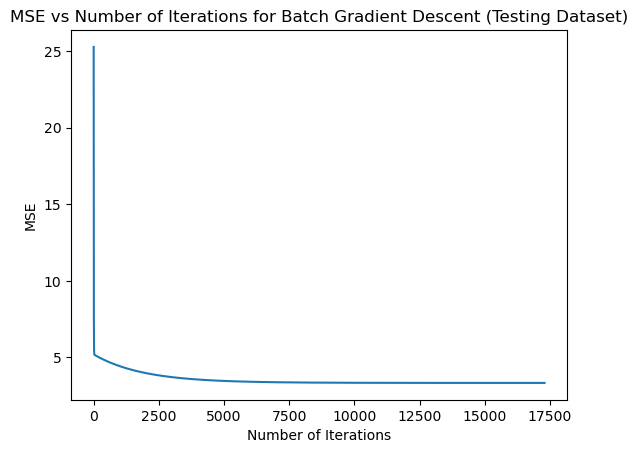

In [22]:
# Extract iteration numbers on testing dataset
iter = [batch_gd_mse_test[i][0] for i in range(len(batch_gd_mse_test))]

# Extract MSE values on the testing dataset
mse = [batch_gd_mse_test[i][1] for i in range(len(batch_gd_mse_test))]

# Plot the data points
plt.plot(iter, mse)
# Set the label for X - axis
plt.xlabel("Number of Iterations")
# Set the label for Y - axis
plt.ylabel("MSE")
# Set the title
plt.title('MSE vs Number of Iterations for Batch Gradient Descent (Testing Dataset)')
plt.show()

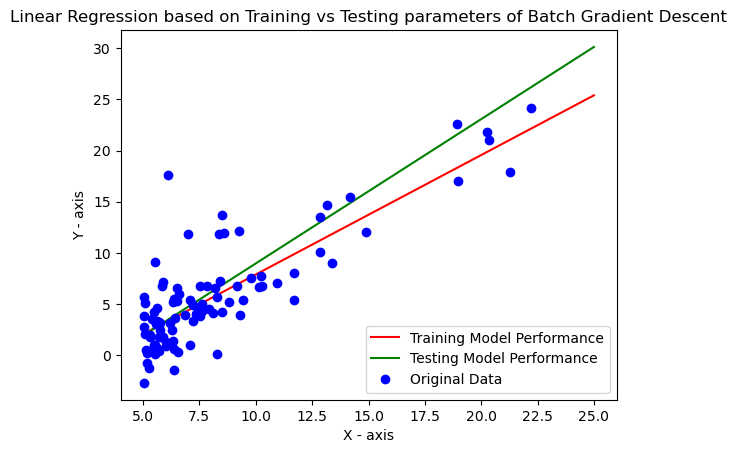

In [23]:
x = np.linspace(5, 25, 1000)

# Plotting the training model performance
plt.plot(x, batch_gd_theta_train[0][0] + x * batch_gd_theta_train[1][0],  color='red', label='Training Model Performance')

# Plotting the testing model performance
plt.plot(x, batch_gd_theta_test[0][0] + x * batch_gd_theta_test[1][0], color='green', label='Testing Model Performance')

# Plotting the original data points
plt.plot(data.x, data.y, 'bo', label='Original Data')  # Added label for clarity

# Set the label for the X-axis
plt.xlabel("X - axis")

# Set the label for the Y-axis
plt.ylabel("Y - axis")

# Set the title for the plot
plt.title('Linear Regression based on Training vs Testing parameters of Batch Gradient Descent')

plt.legend(loc = 'lower right')

plt.show()

MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  4.735983435880435
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  8.836004953475591
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  12.30006455278549
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  15.12816223381012
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  17.32029799654948
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  18.87647184100358
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  19.796683767172407
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  20.08093377505597
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteration:  19.729221864654267
MSE for iteration 0 :  25.2764965564875
Difference in MSE from previous iteratio

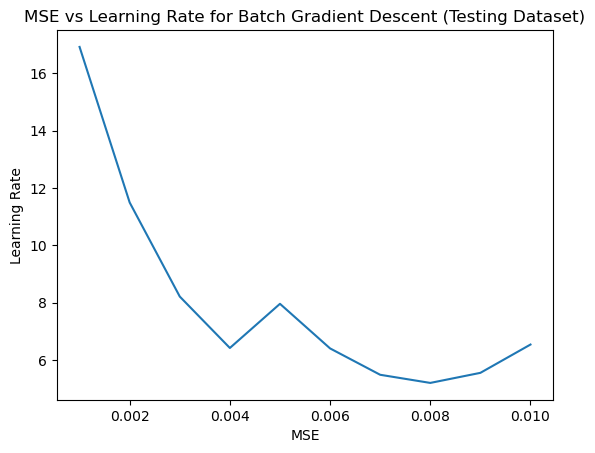

In [24]:
# Batch Gradient Descent with Learning Rate = 0.001
_, batch_gd_mse_test_1 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.001, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.002
_, batch_gd_mse_test_2 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.002, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.003
_, batch_gd_mse_test_3 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.003, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.004
_, batch_gd_mse_test_4 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.004, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.005
_, batch_gd_mse_test_5 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.005, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.006
_, batch_gd_mse_test_6 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.006, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.007
_, batch_gd_mse_test_7 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.007, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.008
_, batch_gd_mse_test_8 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.008, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.009
_, batch_gd_mse_test_9 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.009, threshold = 3.34)
# Batch Gradient Descent with Learning Rate = 0.01
_, batch_gd_mse_test_10 = batch_gradient_descent(X_grad_test, Y_grad_test, learning_rate = 0.01, threshold = 3.34)

# Store the returned values
mse = [batch_gd_mse_test_1[-1][1], batch_gd_mse_test_2[-1][1], batch_gd_mse_test_3[-1][1], batch_gd_mse_test_4[-1][1], batch_gd_mse_test_5[-1][1], batch_gd_mse_test_6[-1][1], batch_gd_mse_test_7[-1][1], batch_gd_mse_test_8[-1][1], batch_gd_mse_test_9[-1][1], batch_gd_mse_test_10[-1][1]]
lr = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]

# Plot the data points
plt.plot(lr, mse)
# Set the label for X - axis
plt.xlabel("MSE")
# Set the label for Y - axis
plt.ylabel("Learning Rate")
# Set the title
plt.title('MSE vs Learning Rate for Batch Gradient Descent (Testing Dataset)')
plt.show()

# Stochastic Gradient Descent

In [25]:
# Transform the dataframe to a numpy array
X = np.array(data.x)
Y = np.array(data.y)

# Reshape the array
X = X.reshape(len(X), 1)
Y = Y.reshape(len(Y), 1)

# np.c_ is used to concatenate arrays along the second axis (columns).
# np.ones((len(data.x), 1)) creates a column of ones to represent the intercept term.
X_grad = np.c_[np.ones((len(X),1)), X]

# Assign the array to the variable
Y_grad = Y

# Split the dataset into training and testing sets
X_grad_train, X_grad_test, Y_grad_train, Y_grad_test = train_test_split(X_grad, Y_grad, test_size=0.2, random_state=50)

In [26]:
def stochastic_gd_predict(theta, X) :
    # Calculate the predictions by performing the dot product between input features and model parameters
    predictions = X.dot(theta)
    return predictions

def stochastic_gd_MSE(predictions, Y) :
    # Compute Sum of Squared Residuals
    mse = np.mean((predictions - Y) ** 2)
    return mse

In [27]:
def stochastic_gradient_descent(X, Y, epochs, learning_rate, threshold):

    # Initialize theta with random values
    theta = np.random.randn(X.shape[1], 1)

    # List to store mean squared error values during training
    stochastic_mse_vals = []

    # Counter for iterations (not used in this version of the code)
    iter = 0

    # Flag to indicate if the stopping condition is met
    flag = False

    # Loop over the number of epochs
    for epoch in range(epochs):

        # If the stopping condition has been met, exit the loop
        if flag is True:
            break

        # Loop over each instance in the dataset
        else:
            for i in range(len(X)):

                # Randomly select an index for stochastic sampling
                random_index = np.random.randint(len(X))

                # Create a single sample for stochastic gradient descent
                X_shuffled = X[random_index:random_index + 1]
                Y_shuffled = Y[random_index:random_index + 1]

                # Make a prediction using the current parameters
                Y_prediction = stochastic_gd_predict(theta, X_shuffled)

                # Calculate the MSE for the current prediction
                current_mse = stochastic_gd_MSE(Y_prediction, Y_shuffled)

                # Check if the MSE is below the threshold
                if current_mse <= threshold:
                    # Set flag to True to exit the loop
                    flag = True
                    print("Condition Satisfied for MSE less than threshold: ", current_mse)
                    # Exit the for loop over the dataset
                    break

                # Calculate the gradient of the loss function with respect to theta
                gradient = 2 * X_shuffled.T.dot(Y_prediction - Y_shuffled)

                # Update the parameters using the gradient and learning rate
                theta = theta - learning_rate * gradient

                # Append the current MSE value to the list for tracking and monitoring
                stochastic_mse_vals.append(current_mse)

    # Return theta and the list of MSE values
    return theta, stochastic_mse_vals

In [28]:
# Call the Stochastic Gradient Descent function on Training Dataset
stochastic_gd_theta_train, stochastic_gd_mse_train = stochastic_gradient_descent(X_grad_train, Y_grad_train, epochs = 1000, learning_rate = 0.001, threshold = 1.0e-8)

In [29]:
print("Optimized Theta for Stochastic Gradient Descent on Training Dataset : ", stochastic_gd_theta_train)

Optimized Theta for Stochastic Gradient Descent on Training Dataset :  [[-3.836452  ]
 [ 1.40588741]]


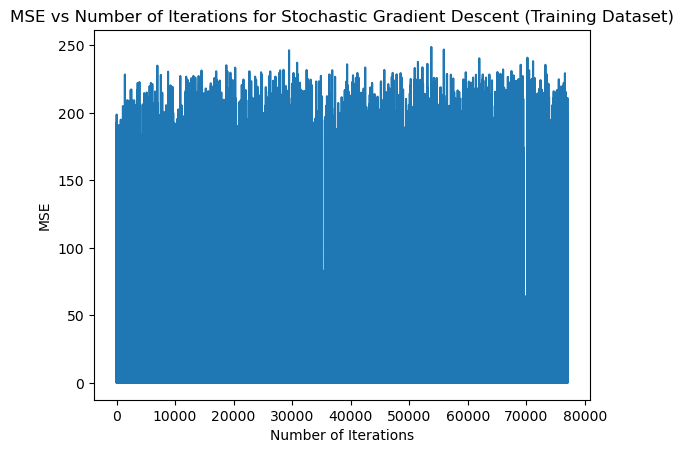

In [30]:
# Store the iteration numbers based on the length of stochastic_gd_mse_train
iter = [i for i in range(len(stochastic_gd_mse_train))]

# Store the MSE values from the stochastic_gd_mse_train list
mse = [stochastic_gd_mse_train[i] for i in range(len(stochastic_gd_mse_train))]

# Plot the data points
plt.plot(iter, mse)
# Set the label for X - axis
plt.xlabel("Number of Iterations")
# Set the label for Y - axis
plt.ylabel("MSE")
# Set the title
plt.title('MSE vs Number of Iterations for Stochastic Gradient Descent (Training Dataset)')
plt.show()

In [31]:
stochastic_gd_theta_test, stochastic_gd_mse_test = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 1000, learning_rate = 0.001, threshold = 1.0e-8)

Condition Satisfied for MSE less than threshold:  9.760660569219843e-09


In [32]:
print("Optimized Theta for Stochastic Gradient Descent on Testing Dataset : ", stochastic_gd_theta_test)
print()
print("Number of Itereations : ", len(stochastic_gd_mse_test))

Optimized Theta for Stochastic Gradient Descent on Testing Dataset :  [[-4.99628344]
 [ 1.34505758]]

Number of Itereations :  13125


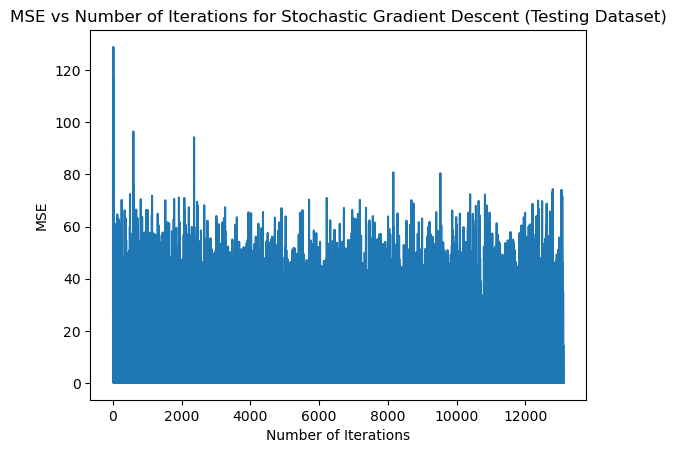

In [33]:
# Store the iteration numbers based on the length of stochastic_gd_mse_test
iter = [i for i in range(len(stochastic_gd_mse_test))]

# Store the MSE values from the stochastic_gd_mse_test list
mse = [stochastic_gd_mse_test[i] for i in range(len(stochastic_gd_mse_test))]

# Plot the data points
plt.plot(iter, mse)
# Set the label for X - axis
plt.xlabel("Number of Iterations")
# Set the label for Y - axis
plt.ylabel("MSE")
# Set the title
plt.title('MSE vs Number of Iterations for Stochastic Gradient Descent (Testing Dataset)')
plt.show()

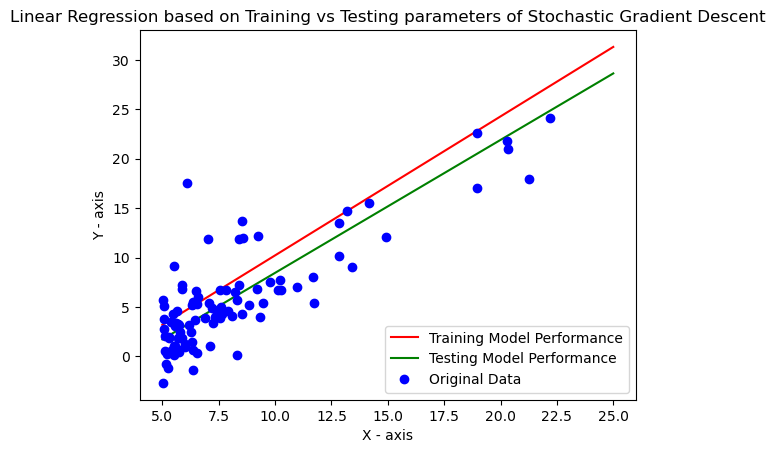

In [34]:
x = np.linspace(5, 25, 1000)

# Plotting the training model performance
plt.plot(x, stochastic_gd_theta_train[0][0] + x * stochastic_gd_theta_train[1][0],  color='red', label='Training Model Performance')

# Plotting the testing model performance
plt.plot(x, stochastic_gd_theta_test[0][0] + x * stochastic_gd_theta_test[1][0], color='green', label='Testing Model Performance')

# Plotting the original data points
plt.plot(data.x, data.y, 'bo', label='Original Data')  # Added label for clarity

# Set the label for the X-axis
plt.xlabel("X - axis")

# Set the label for the Y-axis
plt.ylabel("Y - axis")

# Set the title for the plot
plt.title('Linear Regression based on Training vs Testing parameters of Stochastic Gradient Descent')

plt.legend(loc = 'lower right')

plt.show()

Condition Satisfied for MSE less than threshold:  4.7899298911840467e-11
Condition Satisfied for MSE less than threshold:  5.847708584500827e-11
Condition Satisfied for MSE less than threshold:  2.3497557288439335e-11
Condition Satisfied for MSE less than threshold:  8.496761806095003e-11
Condition Satisfied for MSE less than threshold:  1.1789867095116235e-11
Condition Satisfied for MSE less than threshold:  6.208500716321622e-11
Condition Satisfied for MSE less than threshold:  5.059751178782329e-12
Condition Satisfied for MSE less than threshold:  3.681944696367594e-11
Condition Satisfied for MSE less than threshold:  6.827775651550185e-11
Condition Satisfied for MSE less than threshold:  7.631476217550533e-11


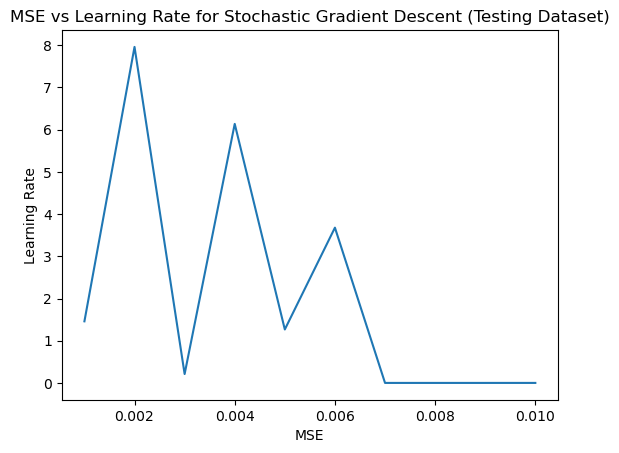

In [35]:
# Stochastic Gradient Descent with Learning Rate = 0.001
_, stochastic_gd_mse_1 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.001, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.002
_, stochastic_gd_mse_2 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.002, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.003
_, stochastic_gd_mse_3 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.003, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.004
_, stochastic_gd_mse_4 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.004, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.005
_, stochastic_gd_mse_5 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.005, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.006
_, stochastic_gd_mse_6 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.006, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.007
_, stochastic_gd_mse_7 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.007, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.008
_, stochastic_gd_mse_8 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.008, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.009
_, stochastic_gd_mse_9 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.009, threshold = 1.0e-10)
# Stochastic Gradient Descent with Learning Rate = 0.01
_, stochastic_gd_mse_10 = stochastic_gradient_descent(X_grad_test, Y_grad_test, epochs = 100000, learning_rate = 0.01, threshold = 1.0e-10)

# Store the returned values
mse = [stochastic_gd_mse_1[-1], stochastic_gd_mse_2[-1], stochastic_gd_mse_3[-1], stochastic_gd_mse_4[-1], stochastic_gd_mse_5[-1], stochastic_gd_mse_6[-1], stochastic_gd_mse_7[-1], stochastic_gd_mse_8[-1], stochastic_gd_mse_9[-1], stochastic_gd_mse_10[-1]]
lr = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]

# Plot the data points
plt.plot(lr, mse)
# Set label for X-axis
plt.xlabel("MSE")
# Set label for Y-axis
plt.ylabel("Learning Rate")
#Set the title
plt.title('MSE vs Learning Rate for Stochastic Gradient Descent (Testing Dataset)')
plt.show()